# Fase 4: Análisis

En esta fase se analiza el dataset limpio para entender la distribución de las variables y su relación con la variable objetivo `Machine failure`.

### Carga del dataset limpio

Se carga el dataset guardado al final de la fase de Data Cleaning.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# Cargamos el dataset limpio que guardamos en la Fase 3
df_clean = pd.read_csv("../data/ai4i2020_clean.csv")
print(f"Dimensiones del dataset limpio: {df_clean.shape[0]} filas y {df_clean.shape[1]} columnas.")

Dimensiones del dataset limpio: 9981 filas y 7 columnas.


## 4.1 Distribución de la variable objetivo

Se estudia cuántos registros corresponden a fallo y cuántos a funcionamiento normal, para saber si las clases están equilibradas.

In [4]:
# Número de registros de cada clase (0 = no falla, 1 = falla)
print(df_clean["Machine failure"].value_counts())

Machine failure
0    9643
1     338
Name: count, dtype: int64


In [5]:
# Porcentaje de cada clase
print(df_clean["Machine failure"].value_counts(normalize=True).round(4) * 100)

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


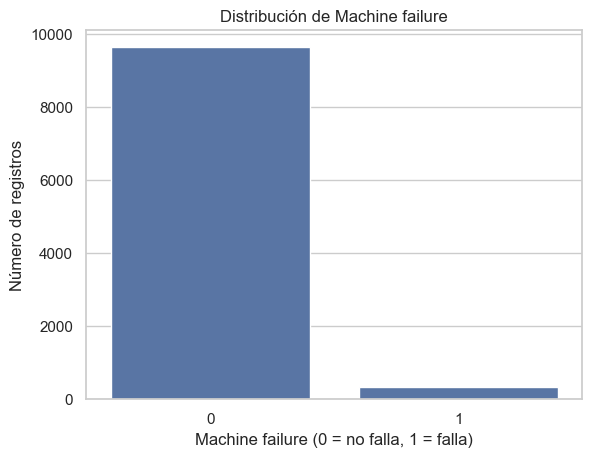

In [6]:
# Gráfico de barras con la distribución
sns.countplot(data=df_clean, x="Machine failure")
plt.title("Distribución de Machine failure")
plt.xlabel("Machine failure (0 = no falla, 1 = falla)")
plt.ylabel("Número de registros")
plt.show()

### Conclusión 4.1: variable objetivo

La variable objetivo está **muy desbalanceada**:

- **Sin fallo (0):** 9.643 registros (96,61 %)
- **Con fallo (1):** 338 registros (3,39 %)

Hay aproximadamente 28,5 registros de funcionamiento normal por cada fallo. Esto tiene consecuencias para el modelado:

- La *accuracy* no será una métrica fiable: un modelo que predijera siempre "no falla" acertaría en torno al 96,6 % sin detectar ningún fallo.
- Habrá que evaluar con métricas que se centren en la clase minoritaria, como *recall*, *precision*, *F1* o *PR-AUC*.
- Al dividir en train y test habrá que usar estratificación (`stratify=y`) para mantener la misma proporción de fallos en ambos conjuntos.
- Podrá ser necesario aplicar alguna técnica de balanceo (por ejemplo, pesos de clase u oversampling).

## 4.2 Variables numéricas: distribución y outliers

Se estudian las cinco variables numéricas: sus estadísticos básicos, su distribución y la presencia de valores atípicos (outliers).

In [7]:
# Lista de variables numéricas del dataset
num_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

# Estadísticos básicos: media, desviación, mínimo, cuartiles y máximo
display(df_clean[num_cols].describe().round(2))

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,9981.0,9981.00,9981.00,9981.00,9981.00
mean,300.0,310.00,1538.88,39.98,107.92
std,2.0,1.48,179.38,9.97,63.64
min,295.3,305.70,1168.00,3.80,0.00
25%,298.3,308.80,1423.00,33.20,53.00
50%,300.1,310.10,1503.00,40.10,108.00
75%,301.5,311.10,1612.00,46.70,162.00
max,304.5,313.80,2886.00,76.60,253.00


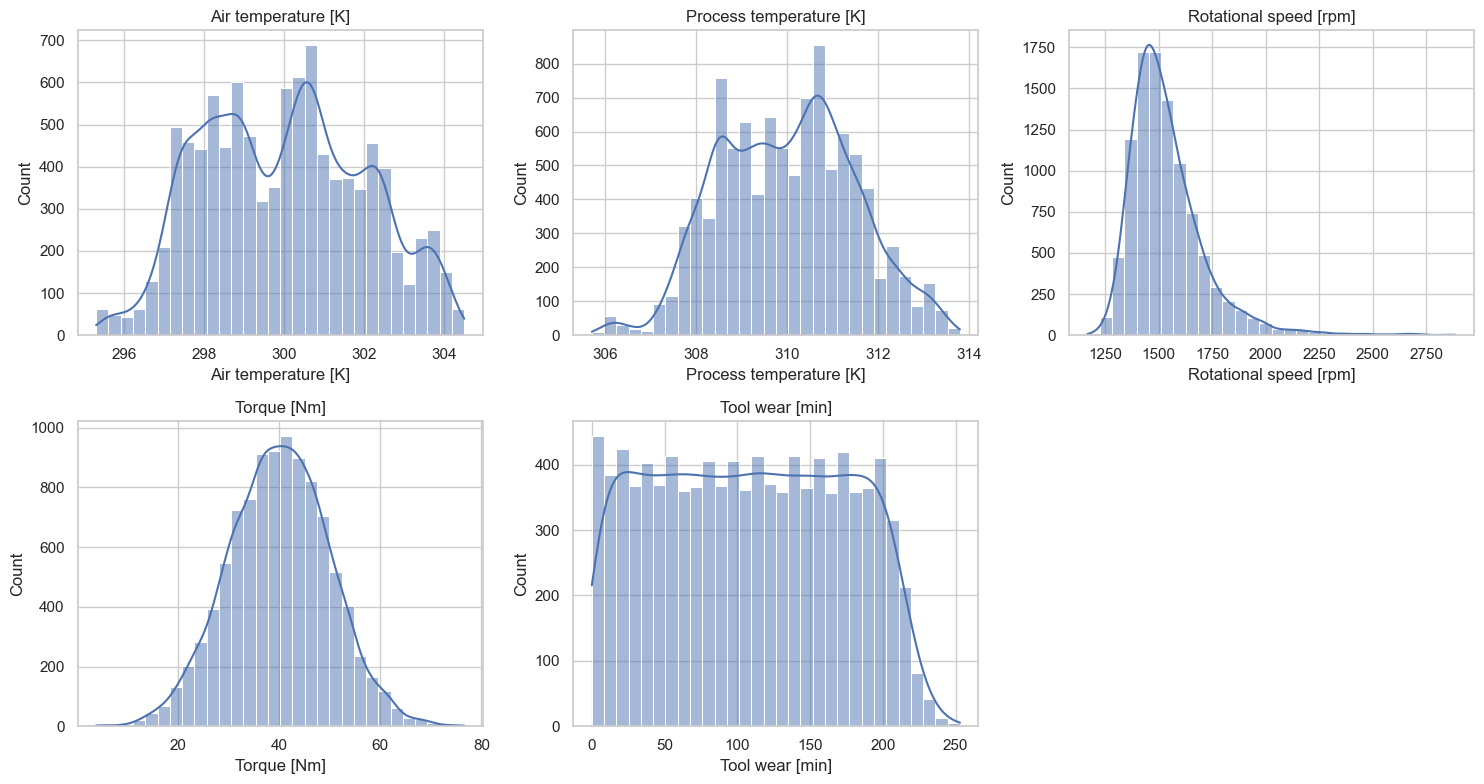

In [8]:
# Histogramas para ver la forma de la distribución de cada variable
# (kde=True añade una línea suavizada sobre las barras)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(data=df_clean, x=col, bins=30, kde=True, ax=ax)
    ax.set_title(col)

# Quitamos el sexto gráfico vacío (hay 5 variables y 6 huecos)
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

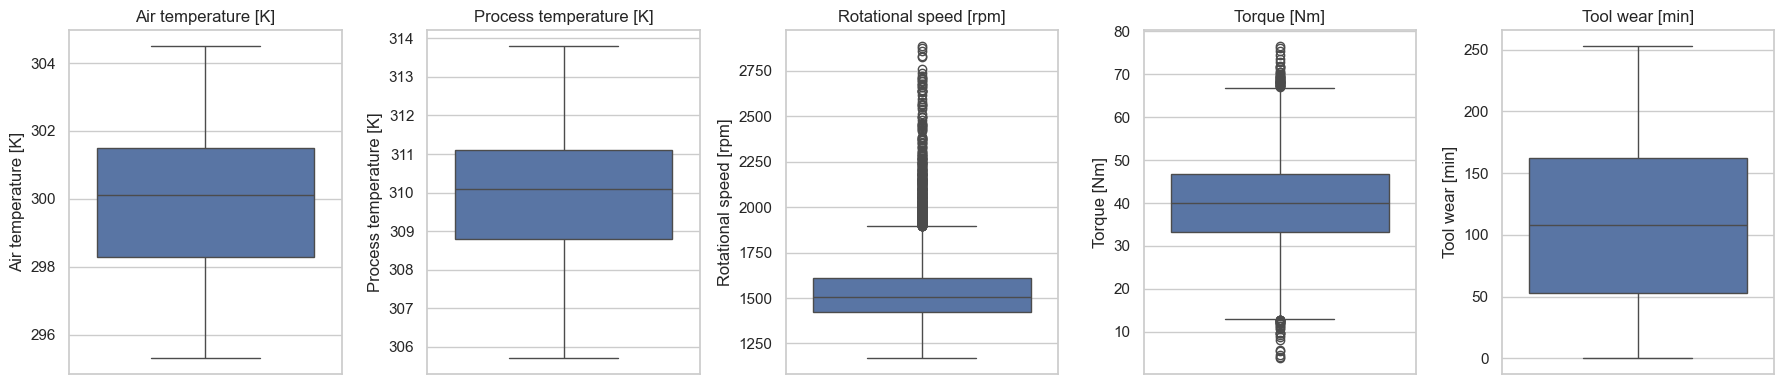

In [9]:
# Boxplots para detectar visualmente los outliers
# (los puntos fuera de los "bigotes" son valores atípicos)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df_clean, y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [10]:
# Contamos los outliers de cada variable con el criterio del rango intercuartílico (IQR):
# un valor es outlier si está por debajo de Q1 - 1.5*IQR o por encima de Q3 + 1.5*IQR
resumen_outliers = []

for col in num_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    n_outliers = ((df_clean[col] < limite_inf) | (df_clean[col] > limite_sup)).sum()
    resumen_outliers.append({
        "variable": col,
        "limite_inferior": round(limite_inf, 2),
        "limite_superior": round(limite_sup, 2),
        "n_outliers": n_outliers,
        "pct_outliers": round(n_outliers / len(df_clean) * 100, 2),
    })

display(pd.DataFrame(resumen_outliers))

,variable,limite_inferior,limite_superior,n_outliers,pct_outliers
0,Air temperature [K],293.50,306.30,0,0.00
1,Process temperature [K],305.35,314.55,0,0.00
2,Rotational speed [rpm],1139.50,1895.50,418,4.19
3,Torque [Nm],12.95,66.95,70,0.70
4,Tool wear [min],-110.50,325.50,0,0.00


In [11]:
# Calculamos el sesgo (skewness) de cada variable numérica:
# - Cerca de 0: distribución simétrica
# - Positivo: cola larga hacia la derecha (valores altos)
# - Negativo: cola larga hacia la izquierda (valores bajos)
sesgo = df_clean[num_cols].skew().round(3)

# Función que traduce el valor numérico a una etiqueta fácil de leer
# (criterio habitual: |sesgo| < 0.5 simétrica, entre 0.5 y 1 moderada, > 1 fuerte)
def interpretar_sesgo(valor):
    if abs(valor) < 0.5:
        return "aproximadamente simétrica"
    elif abs(valor) < 1:
        return "sesgo moderado " + ("positivo" if valor > 0 else "negativo")
    else:
        return "sesgo fuerte " + ("positivo" if valor > 0 else "negativo")

# Tabla resumen con el valor y su interpretación
tabla_sesgo = pd.DataFrame({
    "variable": sesgo.index,
    "sesgo": sesgo.values,
    "interpretacion": [interpretar_sesgo(v) for v in sesgo.values],
})

display(tabla_sesgo)

,variable,sesgo,interpretacion
0,Air temperature [K],0.116,aproximadamente simétrica
1,Process temperature [K],0.016,aproximadamente simétrica
2,Rotational speed [rpm],1.993,sesgo fuerte positivo
3,Torque [Nm],-0.010,aproximadamente simétrica
4,Tool wear [min],0.028,aproximadamente simétrica


### Conclusión 4.2: variables numéricas

**`Air temperature [K]`**
- Media de 300,0 K y mediana de 300,1 K, en un rango de 295,3 a 304,5 K.
- Sesgo de 0,116: aproximadamente simétrica. El histograma muestra varios picos y no tiene una forma de campana clara.
- No presenta outliers según el criterio IQR.

**`Process temperature [K]`**
- Media de 310,0 K y mediana de 310,1 K, en un rango de 305,7 a 313,8 K.
- Sesgo de 0,016: aproximadamente simétrica. Tiene forma de campana aproximada centrada en torno a 310 K, con varios picos pequeños y una pequeña acumulación de valores bajos cerca de 306 K.
- No presenta outliers.

**`Rotational speed [rpm]`**
- Media de 1.538,9 rpm y mediana de 1.503 rpm, en un rango de 1.168 a 2.886 rpm.
- Sesgo de 1,993: es la única variable con un sesgo fuerte positivo. El histograma muestra una cola larga hacia valores altos, con la mayoría de los registros entre 1.300 y 1.700 rpm.
- Presenta 418 outliers (4,19 %), todos por encima del límite superior de 1.895,5 rpm.

**`Torque [Nm]`**
- Media de 39,98 Nm y mediana de 40,1 Nm, en un rango de 3,8 a 76,6 Nm.
- Sesgo de -0,010: simétrica, con forma de campana centrada en torno a 40 Nm.
- Presenta 70 outliers (0,70 %), en ambos extremos.

**`Tool wear [min]`**
- Media de 107,9 min y mediana de 108 min, en un rango de 0 a 253 min.
- Sesgo de 0,028: simétrica, aunque su histograma no es una campana, sino un reparto casi uniforme entre 0 y unos 200 minutos, con una caída a partir de ahí.
- No presenta outliers.

## 4.3 Variable categórica: `Type`

Se estudia cómo se reparten los registros entre las categorías de calidad del producto (L, M y H).

Type
L    5987
M    2995
H     999
Name: count, dtype: int64
Type
L    59.98
M    30.01
H    10.01
Name: proportion, dtype: float64


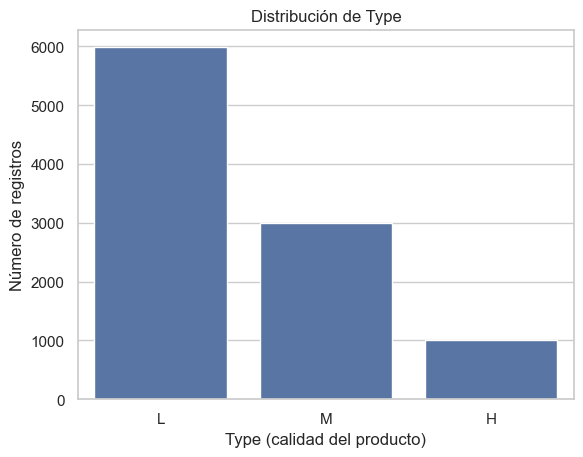

In [17]:
# Número de registros de cada categoría de Type
conteo_type = df_clean["Type"].value_counts()
print(conteo_type)

# Porcentaje de cada categoría sobre el total
print((df_clean["Type"].value_counts(normalize=True) * 100).round(2))

# Gráfico de barras con la distribución de Type
# (order fija el orden de las barras: L, M, H)
sns.countplot(data=df_clean, x="Type", order=["L", "M", "H"])
plt.title("Distribución de Type")
plt.xlabel("Type (calidad del producto)")
plt.ylabel("Número de registros")
plt.show()

### Conclusión 4.3: variable `Type`

La variable `Type` tiene tres categorías y su reparto es claramente desigual:

- **L (calidad baja):** 5.987 registros (59,98 %), la categoría mayoritaria.
- **M (calidad media):** 2.995 registros (30,01 %).
- **H (calidad alta):** 999 registros (10,01 %), la categoría minoritaria.

La categoría L tiene aproximadamente el doble de registros que M, y M tiene aproximadamente el triple que H. En conjunto, la distribución es cercana a un 60 %, 30 % y 10 %.

## 4.4 Relación de las variables con `Machine failure`

Se compara el comportamiento de cada variable entre los registros sin fallo (0) y con fallo (1).

Type
H    2.10
L    3.91
M    2.77
Name: Machine failure, dtype: float64
Type
H     21
L    234
M     83
Name: Machine failure, dtype: int64


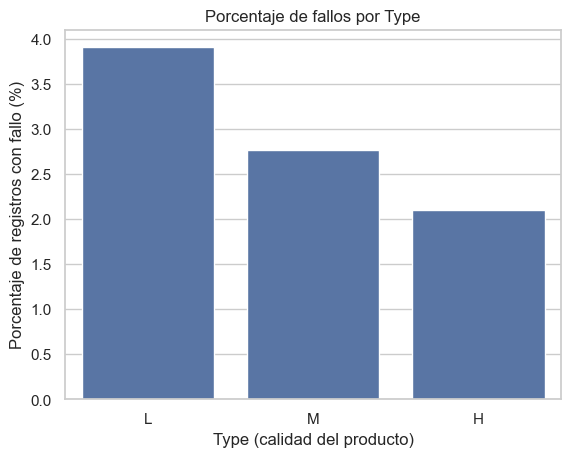

In [15]:
# Porcentaje de registros con fallo dentro de cada categoría de Type
# (la media de una columna de 0 y 1 es la proporción de unos)
tasa_fallo_type = (df_clean.groupby("Type")["Machine failure"].mean() * 100).round(2)
print(tasa_fallo_type)

# Número de fallos en cada categoría de Type
print(df_clean.groupby("Type")["Machine failure"].sum())

# Gráfico de barras con la tasa de fallo por categoría
# (order fija el orden de las barras: L, M, H)
sns.barplot(x=tasa_fallo_type.index, y=tasa_fallo_type.values, order=["L", "M", "H"])
plt.title("Porcentaje de fallos por Type")
plt.xlabel("Type (calidad del producto)")
plt.ylabel("Porcentaje de registros con fallo (%)")
plt.show()

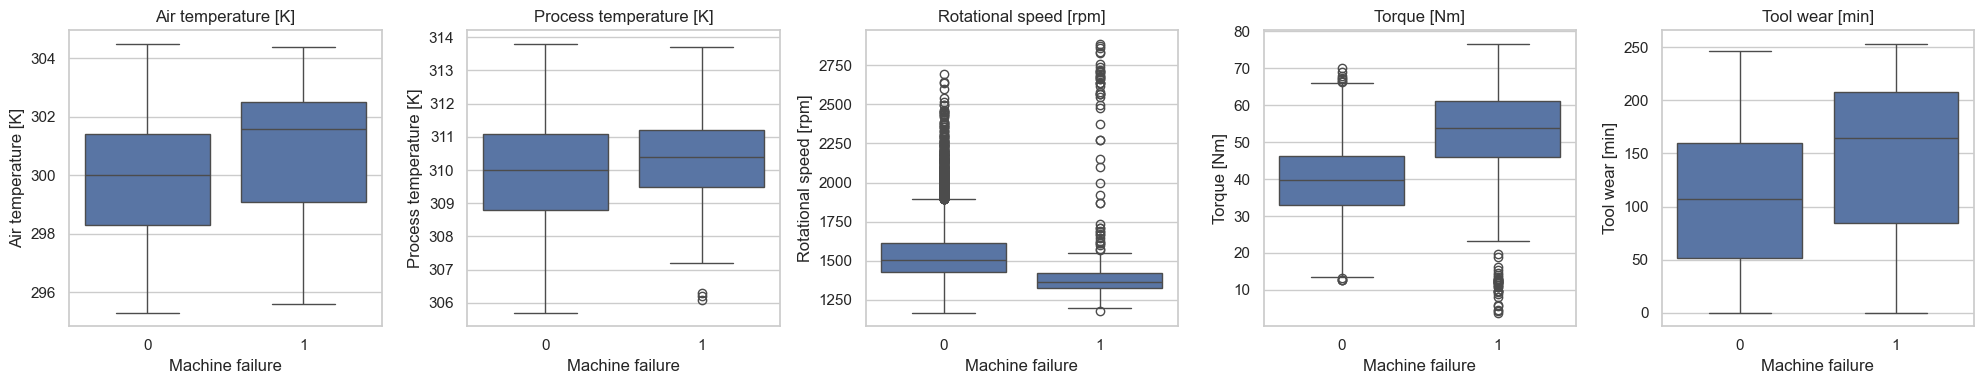

In [18]:
# Un boxplot por variable numérica, comparando los dos grupos
# (0 = no falla, 1 = falla)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df_clean, x="Machine failure", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Machine failure")

plt.tight_layout()
plt.show()

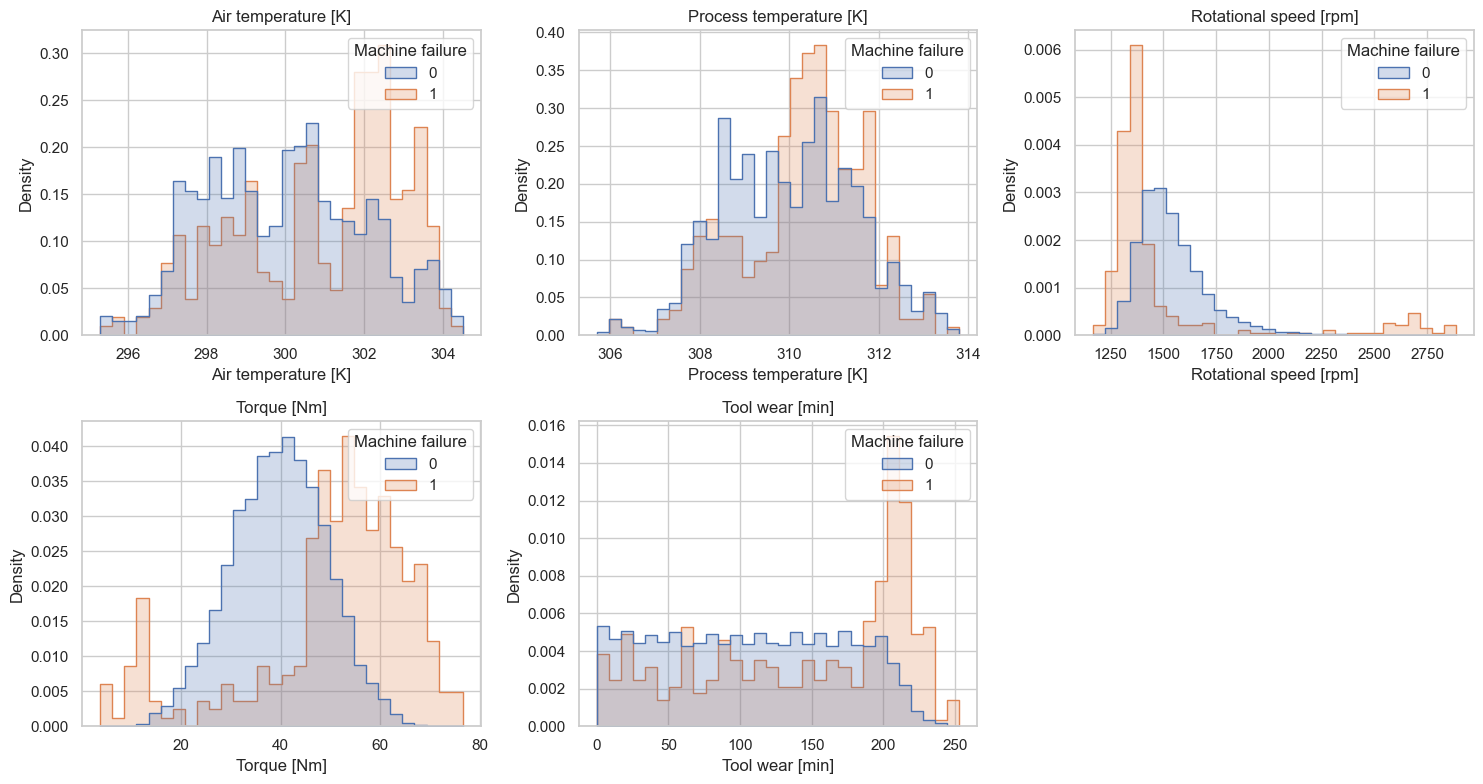

In [19]:
# Histogramas superpuestos de cada variable para los dos grupos
# (stat="density" y common_norm=False permiten comparar las formas
# aunque haya muchos más registros sin fallo que con fallo)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(data=df_clean, x=col, hue="Machine failure", bins=30,
                 stat="density", common_norm=False, element="step", ax=ax)
    ax.set_title(col)

# Quitamos el sexto gráfico vacío
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### Conclusión 4.4.2: variables numéricas y fallos

Las variables no se comportan igual en los registros con fallo (1) que en los que no lo tienen (0). En algunas la diferencia es clara y en otras es pequeña.

**Variables donde los dos grupos se separan más**

- **`Torque [Nm]`:** los fallos tienden a darse con torques más altos. La mediana del grupo con fallo ronda los 54 Nm, frente a unos 40 Nm en el grupo sin fallo. Además, el grupo con fallo muestra un pequeño conjunto de registros con torques muy bajos (por debajo de unos 20 Nm), que aparecen como valores atípicos en el boxplot.
- **`Rotational speed [rpm]`:** los fallos se concentran en velocidades más bajas, alrededor de 1.300-1.400 rpm, con una mediana inferior a la del grupo sin fallo (unos 1.370 rpm frente a unos 1.500 rpm). A la vez, el grupo con fallo tiene un conjunto de registros con velocidades muy altas (entre unos 2.500 y 2.900 rpm).
- **`Tool wear [min]`:** los fallos se asocian con mayor desgaste, con una mediana de unos 165 minutos frente a unos 108 en el grupo sin fallo. El histograma muestra un pico marcado de fallos entre aproximadamente 200 y 220 minutos, mientras que en el grupo sin fallo el desgaste se reparte de forma casi uniforme.

**Variables donde la diferencia es menor**

- **`Air temperature [K]`:** los fallos se dan algo más con temperaturas altas (mediana en torno a 301,6 K frente a unos 300 K), sobre todo entre 302 y 304 K. Aun así, las cajas de ambos grupos se solapan bastante.
- **`Process temperature [K]`:** la diferencia es todavía más pequeña (mediana de unos 310,4 K frente a unos 310 K) y hay un solapamiento muy grande entre los dos grupos. En el grupo con fallo aparecen unos pocos valores atípicos bajos, en torno a 306 K.

**Observaciones generales**

- Los valores atípicos de `Rotational speed` y `Torque` aparecen en los dos grupos, pero en los fallos son más llamativos: hay fallos en ambos extremos de estas dos variables.
- Estas diferencias son asociaciones observadas entre las variables y el fallo, no prueban que una variable cause el fallo.
- El grupo con fallo tiene pocos registros (338) frente al grupo sin fallo, por lo que sus histogramas son más irregulares y conviene interpretarlos con cautela.

## 4.5 Contrastes estadísticos con `Machine failure` - variable objetivo

Se comprueba si las diferencias observadas entre los registros con fallo y sin fallo son estadísticamente significativas, con un nivel de significación de 0,05.

### 4.5.1 Variables numéricas: U de Mann-Whitney

Compara la distribución de cada variable numérica entre los dos grupos (0 = no falla, 1 = falla), sin asumir normalidad. H0: la distribución de la variable es la misma en ambos grupos.

In [20]:
from scipy import stats

# Separamos los registros en dos grupos según Machine failure
grupo_0 = df_clean[df_clean["Machine failure"] == 0]
grupo_1 = df_clean[df_clean["Machine failure"] == 1]

resultados = []

for col in num_cols:
    # Test U de Mann-Whitney (bilateral): compara la distribución de la variable entre grupos
    u, p = stats.mannwhitneyu(grupo_0[col], grupo_1[col], alternative="two-sided")

    # Tamaño del efecto (correlación biserial por rangos): va de -1 a 1
    # Como el p-valor sale muy pequeño con tantos datos, esto indica cuánto de fuerte es la diferencia
    efecto = 1 - (2 * u) / (len(grupo_0) * len(grupo_1))

    resultados.append({
        "variable": col,
        "U": u,
        "p_valor": p,
        "significativa (p<0.05)": p < 0.05,
        "tamaño_efecto": round(efecto, 3),
    })

# Ordenamos por tamaño del efecto en valor absoluto
tabla_mw = pd.DataFrame(resultados)
tabla_mw = tabla_mw.reindex(tabla_mw["tamaño_efecto"].abs().sort_values(ascending=False).index)

display(tabla_mw.style.format({"U": "{:.0f}", "p_valor": "{:.2e}"}))

,variable,U,p_valor,significativa (p<0.05),tamaño_efecto
3,Torque [Nm],748219,2.78e-64,True,0.541000
2,Rotational speed [rpm],2498624,1.59e-62,True,-0.533000
4,Tool wear [min],1103924,5.69e-24,True,0.323000
0,Air temperature [K],1197812,1.09e-16,True,0.265000
1,Process temperature [K],1422390,6.85e-05,True,0.127000


### 4.5.2 `Type`: test chi-cuadrado

Contrasta si `Machine failure` es independiente de la categoría `Type`. H0: son independientes.

In [21]:
# Tabla de contingencia: nº de registros por combinación de Type y Machine failure
tabla_contingencia = pd.crosstab(df_clean["Type"], df_clean["Machine failure"])
print(tabla_contingencia)

# Test chi-cuadrado de independencia
chi2, p_chi, gl, esperados = stats.chi2_contingency(tabla_contingencia)
print(f"\nChi-cuadrado = {chi2:.2f}, grados de libertad = {gl}, p-valor = {p_chi:.4f}")

Machine failure     0    1
Type                      
H                 978   21
L                5753  234
M                2912   83

Chi-cuadrado = 13.49, grados de libertad = 2, p-valor = 0.0012


### Conclusión 4.5: contrastes estadísticos

- **U de Mann-Whitney (variables numéricas):** las cinco variables tienen un p-valor menor que 0,05 (el mayor es 6,85e-05, en `Process temperature [K]`). Todas son significativas: su distribución difiere entre los registros con fallo y sin fallo.
- **Chi-cuadrado (`Type`):** el p-valor es 0,0012, menor que 0,05, por lo que también es significativa: `Type` y `Machine failure` no son independientes.